# MSc Artificial Intelligence Dissertation

## Notebook 01

# Dataset Understanding and Data Quality Assessment

---

### Dissertation Title

**Multi-Modal Credit Risk Prediction Using Structured and Textual Data: Explainability, Calibration, and Decision Support**

### Student

**Debasish Mohanty**

### University

**Liverpool John Moores University**

### Programme

**MSc Artificial Intelligence**

### Dataset

**LendingClub Accepted Loans (2007–2018)**

### Notebook Objective

To evaluate the suitability of the LendingClub dataset for hybrid credit risk prediction using structured borrower information and borrower-written loan descriptions.

### Related Research Objective

**O1 – Prepare a LendingClub dataset containing structured borrower and loan variables together with loan-description text suitable for default prediction.**


# Introduction

This notebook performs the initial exploratory analysis and data-quality assessment of the LendingClub dataset. Its purpose is to determine whether the dataset is suitable for the multi-modal credit risk prediction framework defined in the approved research proposal.

The notebook evaluates:

- dataset dimensions and structure;
- availability of the target and textual variables;
- target-variable definition;
- availability and quality of borrower-written loan descriptions;
- description uniqueness and length; and
- initial considerations for feature auditing and target-leakage prevention.

The findings provide the methodological foundation for all subsequent preprocessing, feature engineering, modelling, explainability, calibration, and decision-support activities.


# 1. Research Information

## Research Project

**Multi-Modal Credit Risk Prediction Using Structured and Textual Data: Explainability, Calibration, and Decision Support**

## Dataset

LendingClub Accepted Loans, 2007–2018

## Dataset File

`accepted_2007_to_2018Q4.csv`

## Research Objective

O1 – Prepare the LendingClub dataset containing structured borrower and loan variables together with loan-description text suitable for default prediction.

## Notebook Goal

Understand and assess the dataset before preprocessing or model development.


## Key Findings

- The notebook scope is explicitly aligned with the approved research proposal.
- The LendingClub dataset is the primary data source for the study.
- The analysis focuses on assessing whether the dataset can support structured-only, TF-IDF-enhanced, and BERT-enhanced credit-risk experiments.


# 2. Research Environment and Library Imports


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Credit_Risk_Thesis")

folders = [
    base_path / "data" / "raw",
    base_path / "data" / "processed",
    base_path / "notebooks",
    base_path / "outputs" / "figures",
    base_path / "outputs" / "tables",
    base_path / "outputs" / "models",
    base_path / "paper"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [3]:
## Another option to use the dataset directly from Kagglehub instead of downloading locally.
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("wordsforthewise/lending-club")

# print("Path to dataset files:", path)

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Key Findings

- Google Drive was mounted successfully to provide persistent storage.
- A reproducible project folder structure was created for raw data, processed data, notebooks, figures, tables, models, and dissertation material.
- Pandas and NumPy were imported for data manipulation and analysis, while Matplotlib was imported for visualisation.
- Additional NLP, modelling, explainability, and calibration libraries will be introduced only when required in later notebooks.


# 3. Dataset Loading


In [5]:
raw_data_path = base_path / "data" / "raw"

for file in raw_data_path.iterdir():
    print(file.name)

accepted_2007_to_2018Q4.csv


In [ ]:
dataset_path = "/content/drive/MyDrive/Credit_Risk_Thesis/data/raw/accepted_2007_to_2018Q4.csv"

df = pd.read_csv(
    dataset_path,
    low_memory=False
)

## Key Findings

- The LendingClub dataset was loaded successfully from a fixed Google Drive path.
- The original dataframe is retained as the unmodified source dataset.
- All later filtering and preprocessing will be performed on copies to preserve data integrity and reproducibility.


# 4. Dataset Overview

## Purpose

Establish the scale of the dataset and assess whether it is sufficiently large for structured and text-enhanced credit-risk modelling.


In [ ]:
print(df.shape)

(2260701, 151)


## Discussion

The LendingClub dataset contains **2,260,701 loan records** and **151 attributes**. Its scale is sufficient for statistically meaningful machine-learning experiments. The presence of a large number of attributes also indicates that systematic feature auditing will be essential before modelling, particularly to distinguish origination-time variables from post-origination variables that could introduce target leakage.

## Key Findings

- The dataset contains 2,260,701 observations.
- The dataset contains 151 variables.
- The sample size is sufficient for structured modelling and for constructing a sizeable text-available experimental cohort.

## Research Implication

The dataset is suitable for the proposed comparative framework, but its dimensionality requires a formal feature-inventory and leakage-analysis stage before preprocessing.

## Next Step

Inspect the dataset structure, data types, and complete feature list.


# 5. Dataset Structure

## Purpose

Examine the dataset schema, variable types, and complete feature list to prepare for target definition and feature categorisation.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [ ]:
df.dtypes.value_counts()

,count
float64,113
object,38


In [ ]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

## Discussion

The dataset contains a mixture of numerical, categorical, date-like, identifier, repayment, and textual variables. This heterogeneous structure supports multi-modal modelling but also creates methodological challenges. Categorical encoding, missing-value handling, temporal interpretation, and leakage prevention must therefore be treated as explicit stages rather than as ad hoc implementation choices.

## Key Findings

- The dataset contains mixed data types, including numeric and object variables.
- Variables represent borrower characteristics, loan characteristics, credit history, repayment behaviour, administrative information, and free text.
- The complete list of 151 features provides the input for the later feature-audit process.

## Research Implication

Features cannot be selected solely on the basis of statistical association. They must first be classified according to temporal availability and relevance at loan origination.

## Next Step

Verify the presence of the target and textual fields, then define the binary prediction target.


# 6. Target Variable Analysis

## Purpose

Examine the distribution of loan outcomes and define a defensible target variable for binary default prediction.

## Research Question

Which loan-status categories represent completed outcomes suitable for supervised binary credit-risk modelling?


In [ ]:
print("loan_status" in df.columns)

print("desc" in df.columns)

True
True


In [ ]:
loan_status_counts = df["loan_status"].value_counts(dropna=False)

loan_status_counts

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


## Discussion

The raw `loan_status` field contains completed, active, delinquent, and unresolved loan states. For a binary model that predicts final default outcome, active and intermediate statuses introduce label ambiguity because their eventual outcomes are unknown at the time of the dataset snapshot.

`Fully Paid` and `Charged Off` provide completed outcomes and therefore form the most defensible binary target. `Current`, `Late`, and `In Grace Period` remain relevant for later behavioural or secondary validation, but they should not be treated as definitive binary labels in the primary supervised-learning cohort.


In [ ]:
# Keep only completed loans

df_model = df[
    df["loan_status"].isin(
        [
            "Fully Paid",
            "Charged Off"
        ]
    )
].copy()

print(df_model.shape)

(1345310, 151)


## Key Findings

- `Fully Paid` and `Charged Off` are the two dominant completed loan outcomes.
- `Current`, `Late`, and `In Grace Period` represent unresolved or intermediate states.
- The binary modelling target is defined as:
  - `Fully Paid` → non-default (0)
  - `Charged Off` → default (1)

## Research Implication

Using completed outcomes reduces label ambiguity and ensures that predictive performance is evaluated against known repayment results. The approve/review/reject decision-support layer will later be derived from calibrated default probabilities rather than from these raw status categories.

## Next Step

Audit the availability and usability of borrower-written loan descriptions.


## Research Decision Log

### RD-001 – Binary Target Definition

**Decision:** Use only `Fully Paid` and `Charged Off` loans for primary supervised model training.

**Reason:** These categories represent completed repayment outcomes. Active, late, and grace-period loans do not yet have definitive final outcomes and would introduce label ambiguity.

**Alternative Considered:** Treating late or grace-period loans as default or review labels.

**Reason Rejected:** These are post-origination intermediate states and may later resolve either positively or negatively. They are therefore unsuitable as definitive origination-time binary labels.

**Impact on Research:** The primary modelling problem remains binary default prediction. The calibrated predicted probability will later be mapped to approve, review, and reject categories.


# 7. Text Availability Analysis

## Purpose

Determine whether the `desc` field provides enough borrower-written text to support TF-IDF and BERT-based experiments.

## Research Question

Is there a sufficiently large text-available subset for a fair comparison of structured-only and text-enhanced credit-risk models?


In [ ]:
# Number of non-null descriptions
df["desc"].notna().sum()

np.int64(126065)

In [ ]:
# Percentage of non-null descriptions
(df["desc"].notna().sum() / len(df)) * 100

np.float64(5.576367684182914)

## Discussion

Borrower descriptions are available for **126,065 loans**, representing approximately **5.58%** of the full dataset. Although the proportion is small, the absolute number of records is large enough for meaningful NLP experimentation. The limited coverage also indicates that the text-enhanced experiments must use a carefully defined common cohort so that structured-only and hybrid models are compared on the same observations.

## Key Findings

- 126,065 records contain non-null descriptions.
- Text is available for approximately 5.58% of all loans.
- The available text volume is sufficient for TF-IDF and contextual embedding experiments.

## Research Implication

The primary model comparison will use the same text-available completed-loan cohort across structured-only, TF-IDF-enhanced, and BERT-enhanced models. Text sparsity will be reported as a dataset limitation.

## Next Step

Inspect random descriptions to assess whether they contain meaningful borrower narratives or mainly system-generated templates.


# 8. Description Quality Analysis

## Research Motivation

A non-null description is not necessarily meaningful. Manual inspection and uniqueness analysis are required to identify borrower-generated content, duplicated templates, HTML artefacts, system-generated prefixes, and empty-looking records.


In [ ]:
# Print 100 random borrower descriptions
sample_desc = df["desc"].dropna().sample(100, random_state=42)

for i, text in enumerate(sample_desc, start=1):
    print(f"{i}. {text}\n")

1. I've ended up with a few loans from different places, and with relatively poor interest rates in retrospect. I would like to have one convenient payment per month, and hopefully a better interest rate.  I am paying off a small personal loan, a bit of credit card balance, and a loan used to buy a Marimba One 5 octave marimba for my wife (a recent music graduate).   I have very good credit and steady income, I would just like to consolidate a few things.  Thanks for your consideration!

2.   Borrower added on 10/29/13 > We have incurred a credit card loan over the past 10 yrs to Capital One.  The interest rate is high.  We want to pay the loan but not all the interest that Capital One charges.  We got into this debt helping my parents and brother.<br>

3.  385521 added on 10/17/09 > I plan to use this money to pay off credit cards and consolidate debt.  After this I will close my accounts.  I am a teacher with a stedy full time job and have always paid my bills on time and in full. 38

In [ ]:
# Count descriptions by loan status

text_by_status = (
    df[df["desc"].notna()]
    .groupby("loan_status")
    .size()
    .sort_values(ascending=False)
)

text_by_status

,0
loan_status,
Fully Paid,104595
Charged Off,18935
Does not meet the credit policy. Status:Fully Paid,1749
Does not meet the credit policy. Status:Charged Off,674
Current,91
Late (31-120 days),12
In Grace Period,6
Late (16-30 days),3


In [ ]:
# Percentage within each status

text_percentage = (
    df[df["desc"].notna()]
    .groupby("loan_status")
    .size()
    /
    df.groupby("loan_status").size()
    *100
).round(2)

text_percentage.sort_values(ascending=False)

,0
loan_status,
Does not meet the credit policy. Status:Charged Off,88.57
Does not meet the credit policy. Status:Fully Paid,87.98
Fully Paid,9.71
Charged Off,7.05
Late (16-30 days),0.07
In Grace Period,0.07
Late (31-120 days),0.06
Current,0.01
Default,NaN


In [ ]:
# Number of unique descriptions

print(df["desc"].nunique())

# Percentage of unique descriptions.
print(df["desc"].nunique() / df["desc"].notna().sum() * 100)

124500
98.7585769246024


In [ ]:
# Most frequent descriptions

df["desc"].value_counts().head(20)

,count
desc,
,252
Debt Consolidation,13
Borrower added on 03/17/14 > Debt consolidation<br>,11
Borrower added on 03/10/14 > Debt consolidation<br>,10
Borrower added on 02/19/14 > Debt consolidation<br>,9
Camping Membership,8
Borrower added on 01/29/14 > Debt consolidation<br>,8
Borrower added on 01/15/14 > Debt consolidation<br>,7
Borrower added on 01/22/14 > Debt consolidation<br>,7


## Discussion

The random samples show that the `desc` field contains genuine borrower narratives concerning debt consolidation, home improvement, medical costs, and other borrowing purposes. The field also contains HTML tags and system-generated text such as “Borrower added on...”, which must be removed during text preprocessing.

The dataset contains **124,500 unique descriptions** among **126,065 non-null descriptions**, corresponding to approximately **98.76% uniqueness**. This indicates that exact duplication is limited and reduces the risk that text models will succeed merely by memorising repeated templates.

The status-level analysis confirms that almost all usable descriptions belong to completed `Fully Paid` and `Charged Off` loans, producing a text-available completed-loan cohort of approximately 123,530 records.

## Key Findings

- The descriptions contain meaningful borrower-written narratives.
- Raw text includes HTML and LendingClub-generated metadata that require cleaning.
- Approximately 98.76% of non-null descriptions are unique.
- Most usable text belongs to completed loan outcomes.

## Research Implication

The text is suitable for NLP analysis, but a reproducible cleaning pipeline is necessary before TF-IDF or BERT representation. Exact duplication is not a major threat, although normalised duplicates should be reassessed after cleaning.

## Next Step

Analyse description length to guide cleaning thresholds and later BERT token-length decisions.


# 9. Description Length Analysis

## Purpose

Characterise the length distribution of borrower descriptions and assess their suitability for traditional and contextual text representations.


In [ ]:
df_text = df[df["desc"].notna()].copy()

df_text["word_count"] = (
    df_text["desc"]
    .str.split()
    .str.len()
)

df_text["word_count"].describe()

,word_count
count,126065.000000
mean,42.807060
std,48.723689
min,0.000000
25%,16.000000
50%,29.000000
75%,53.000000
max,815.000000


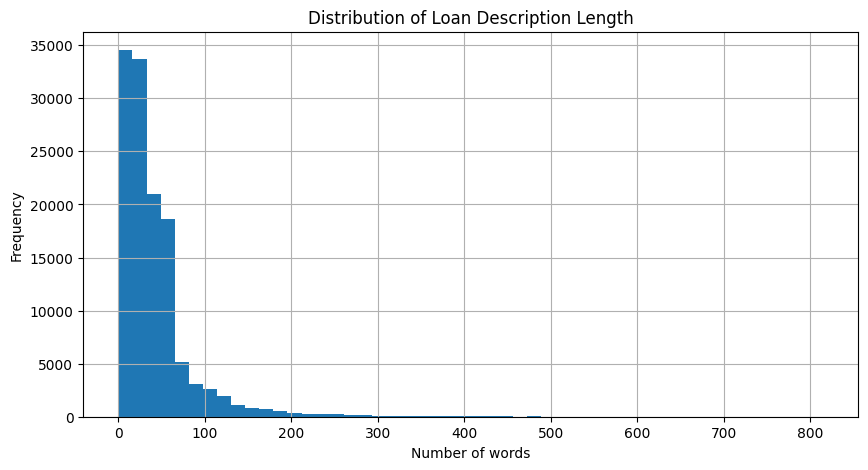

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df_text["word_count"].hist(
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Distribution of Loan Description Length")

plt.show()

**Figure 1. Distribution of Borrower Loan-Description Length**

## Discussion

The mean description length is approximately **42.8 words**, while the median is **29 words**. The difference between the mean and median, together with the histogram, indicates a strongly right-skewed distribution. Most descriptions are relatively short, while a small number are substantially longer, with a maximum of 815 words.

The minimum word count of zero indicates that non-null filtering alone does not guarantee meaningful textual content. Some records may contain only whitespace, HTML, or other artefacts. These cases must be reassessed after cleaning.

## Key Findings

- Mean description length is approximately 42.8 words.
- Median description length is 29 words.
- The distribution is strongly right-skewed.
- Most descriptions are short to medium length, supporting TF-IDF and contextual text representation.
- A small number of non-null records contain zero raw words or unusually long descriptions.

## Research Implication

No descriptions should be removed solely because they are long before further analysis. For BERT, maximum sequence length will later be selected using tokenizer-based token percentiles rather than raw word counts. Empty and artefact-only descriptions will be removed after cleaning.

## Next Step

Create a formal feature inventory and classify all variables by temporal availability and leakage risk.


# 10. Feature Inventory and Target-Leakage Preparation

## Purpose

Create a complete inventory of the 151 variables so that each feature can be classified as:

- **Keep** – available at or before loan origination and relevant to prediction;
- **Remove** – identifier, administrative, post-origination, repayment, recovery, or other leakage-prone information; or
- **Review** – requires methodological justification before inclusion.

## Research Question

Which LendingClub variables are genuinely available at loan origination, and which would introduce information unavailable when an approval decision is made?


In [ ]:
feature_inventory = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": [str(dtype) for dtype in df.dtypes],
    "Category": "Review",
    "Decision": "Pending",
    "Reason": ""
})

feature_inventory.head()


,Feature,Data_Type,Category,Decision,Reason
0,id,object,Review,Pending,
1,member_id,float64,Review,Pending,
2,loan_amnt,float64,Review,Pending,
3,funded_amnt,float64,Review,Pending,
4,funded_amnt_inv,float64,Review,Pending,


In [ ]:
feature_inventory_path = base_path / "outputs" / "tables" / "feature_inventory.csv"
feature_inventory.to_csv(feature_inventory_path, index=False)
print(f"Feature inventory saved to: {feature_inventory_path}")


Feature inventory saved to: /content/drive/MyDrive/Credit_Risk_Thesis/outputs/tables/feature_inventory.csv


## Discussion

This section initializes, but does not yet complete, the feature-audit process. Formal categorisation will be performed in Notebook 02 because feature suitability requires careful examination of temporal availability, operational meaning, and leakage risk.

## Key Findings

- A structured inventory has been created for all 151 variables.
- Each variable will receive a documented keep/remove/review decision.
- Feature selection will be based on methodological availability at loan origination, not merely on predictive strength.

## Research Implication

A formal audit reduces the risk of unrealistically high performance caused by repayment or recovery information that would not be available when an application is assessed.

## Next Step

Complete the feature audit and target-leakage analysis in Notebook 02.


# 11. Notebook Summary

## Objective Achieved

Notebook 01 successfully assessed the suitability of the LendingClub dataset for the proposed multi-modal credit risk study.

## Major Findings

- The dataset contains 2,260,701 loan records and 151 variables.
- `loan_status` and `desc`, the two essential fields for the proposed study, are present.
- The primary binary target will use `Fully Paid` and `Charged Off` as completed outcomes.
- 126,065 records contain non-null descriptions, equivalent to approximately 5.58% of the complete dataset.
- Approximately 98.76% of available descriptions are unique.
- Borrower descriptions contain meaningful narrative information but also include HTML and system-generated artefacts.
- Description lengths are generally suitable for TF-IDF and contextual text representations.
- A text-available completed-loan cohort of approximately 123,530 records is available for the primary controlled model comparison.

## Research Decisions

### RD-001 – Binary Target Definition

Use only `Fully Paid` and `Charged Off` for primary supervised training.

### RD-002 – Common Experimental Cohort

Use the same completed-loan, text-available observation set for the primary comparison of structured-only, TF-IDF-enhanced, and BERT-enhanced models.

## Limitations Identified

- Borrower descriptions are available for only approximately 5.58% of all records.
- The text-available sample is concentrated in earlier LendingClub periods, creating potential selection and temporal bias.
- Raw descriptions contain HTML, system-generated metadata, and a small number of empty or artefact-only records.
- The experimental conclusions may not generalise to the full LendingClub population or to later lending periods without borrower descriptions.

## Contribution to the Dissertation

This notebook establishes the dataset characteristics, target definition, text feasibility, and initial data-quality considerations that underpin the methodology chapter and all subsequent experiments.

## Next Notebook

**Notebook 02 – Feature Audit and Target Leakage Analysis**

The next notebook will:

- classify all 151 variables;
- identify origination-time predictors;
- remove identifiers and post-origination leakage variables;
- justify review-status variables; and
- freeze the candidate feature set for preprocessing and modelling.
